# Teoría de colas: Redes de Jackson

En esta sección, extendemos los modelos de colas individuales al caso de **redes de colas**: sistemas donde los clientes transitan por *múltiples servidores*, posiblemente formando colas en cada uno. Las **Redes de Jackson** son la clase más importante de redes de colas con solución exacta en forma de producto.

In [1]:
#using Pkg;Pkg.instantiate(); Pkg.update()

## Motivación

En muchas aplicaciones los clientes no son atendidos por un único servidor sino que recorren una secuencia de etapas:

* Un paquete de datos atraviesa varios routers en Internet.
* Un trabajo de manufactura pasa por varias máquinas en una fábrica.
* Una transacción web pasa por ejemplo por un balanceador, un servidor de aplicación y consultas a una base de datos.

La pregunta natural es: ¿podemos analizar el comportamiento en estado estacionario de toda la red?,

**Problema:** el estado del sistema tiene que tener en cuenta la ocupación de cada uno de los subsistemas presentes.

¿Cómo hacemos para resolver esta Cadena de Markov de alta dimensión?


## Modelo

Una **Red de Jackson abierta** con $J$ nodos consiste en:

 * En cada nodo $j = 1,\ldots,J$ hay **un servidor** con tiempos de servicio exponenciales de tasa $\mu_j$, disciplina FIFO.
 * Llegan clientes externos al nodo $j$ según un proceso de Poisson de tasa $\nu_j \geqslant 0$. Se asume que al menos un nodo recibe clientes externos.
 * Cuando un cliente termina de ser atendido en el nodo $j$, se dirige al nodo $k$ con probabilidad $r_{jk}$, o abandona la red ("sale") con probabilidad $d_j = 1 - \sum_{k=1}^J r_{jk} \geqslant 0$.
 * Todos los tiempos de arribo y servicio son *independientes*. En particular, al cambiar de servidor se sortea nuevamente el tiempo de servicio.


### Matriz de Ruteo

Las probabilidades $r_{jk}$ forman la **matriz de ruteo**:

$$R = (r_{jk})_{J \times J}$$

con $r_{jk} \geqslant 0$ y $\sum_k r_{jk} \leqslant 1$ para todo $j$.

**Observación:** no necesariamente todos los nodos $j$ tienen salidas.

### Ejemplo

![jackson net](../images/jackson.png)

### Estado del sistema

El **estado** del sistema en el instante $t$ es el vector:

$$\mathbf{n}(t) = (n_1(t), \ldots, n_J(t)) \in \mathbb{N}^J,$$

donde $n_j(t)$ es el número de clientes en el nodo $j$ (en cola más en servicio). Este es una cadena de Markov de tiempo continuo.

### Tasas de transición

Sea $\mathbf{e}_j$ el vector que tiene solamente un $1$ en la coordenada $j$ (vector canónico). Entonces las tasas de transición de la cadena anterior son:

Arribos a una cola:
$$\mathbf{n} \mapsto \mathbf{n}+\mathbf{e}_j :\quad \nu_j$$

Transición de una cola a otra:
$$\mathbf{n} \mapsto \mathbf{n}-\mathbf{e}_j + \mathbf{e}_k: \quad r_{ij}\mu_i \mathbf{1}_{\{n_i>0\}}$$
Partidas de una cola:
$$\mathbf{n} \mapsto \mathbf{n}-\mathbf{e}_j :\quad \mu_j \mathbf{1}_{\{n_j>0\}}$$

### Ecuaciones de tráfico

Sea $\lambda_j$ a la **tasa total de llegadas** al nodo $j$: la suma de las llegadas externas más las que provienen de otros nodos.

* Si el sistema llega a régimen, la tasa de salida de la cola $j$ deberá ser igual a su tasa de entrada $\lambda_j$.
* Por lo tanto, la tasa de tráfico de $j\to k$ es $\lambda_j r_{jk}$.

Esto permite definir las ecuaciones de tráfico:
$$\lambda_j = \nu_j + \sum_{i=1}^{J} \lambda_i \, r_{ij}, \quad j = 1, \ldots, J$$

En forma matricial, definiendo $\boldsymbol{\lambda} = (\lambda_1,\ldots,\lambda_J)^T$ y $\boldsymbol{\nu} = (\nu_1,\ldots,\nu_J)^T$:

$$\boldsymbol{\lambda} = \boldsymbol{\nu} + R^T \boldsymbol{\lambda} \implies (I - R^T)\boldsymbol{\lambda} = \boldsymbol{\nu}$$

### Solución de la ecuación de tráfico:


**Proposición.** Bajo las hipótesis del modelo, el sistema $(I - R^T)\boldsymbol{\lambda} = \boldsymbol{\nu}$ tiene solución única no negativa.

**Demostración.** Interpretamos $R$ como la matriz de transición de una **cadena de Markov de tiempo discreto** sobre el conjunto de nodos $\{1,\ldots,J\}$ aumentado con un estado absorbente $\{0\}$ ("salida de la red"). La cadena describe el recorrido de un cliente: empieza en algún nodo, salta de nodo en nodo con probabilidades $r_{jk}$, y en cada paso sale con probabilidad $d_j = 1 - \sum_k r_{jk} > 0$.

Como $d_j > 0$ para todo $j$, desde cualquier nodo hay probabilidad positiva de ir al estado absorbente $\{0\}$ en un solo paso. Por lo tanto **todos los estados $\{1,\ldots,J\}$ son transitorios**: todo cliente eventualmente abandona la red con probabilidad 1.

De la teoría de cadenas de Markov, si $\{1,\ldots,J\}$ son todos transitorios, la submatriz de transición entre ellos (que es exactamente $R$) satisface $\rho(R) < 1$ (radio espectral estrictamente menor que 1). Esto implica que la serie de Neumann converge:

$$(I - R)^{-1} = \sum_{k=0}^{\infty} R^k$$

y por lo tanto $(I - R)$ —y también $(I - R^T)$— son invertibles. La solución única es:

$$\boldsymbol{\lambda} = (I - R^T)^{-1} \boldsymbol{\nu}$$

La no negatividad se sigue de que $(I-R)^{-1} = \sum_k R^k$ tiene todos sus elementos no negativos (es una suma de potencias de una matriz no negativa). $\blacksquare$

### Interpretación probabilística

El elemento $[(I-R^T)^{-1}]_{jk} = \sum_{n=0}^\infty [R^n]_{jk}$ es el **número esperado de visitas al nodo $k$** de un cliente que empieza en el nodo $j$. Entonces $\nu_j$ es la tasa de llegadas externas ponderada por el número esperado de visitas:

$$\lambda_j = \sum_{k=1}^J \nu_k \cdot \mathbb{E}[\text{visitas a } j \mid \text{entra por } k]$$

## 4. Teorema de Jackson

### Enunciado

**Teorema (Jackson, 1957).** Sea una red de Jackson abierta con $J$ nodos M/M/1. Sea $\boldsymbol{\lambda}$ la solución de las ecuaciones de tráfico y supongamos que $\rho_j = \lambda_j/\mu_j < 1$ para todo $j$. Entonces la cadena de Markov $(\mathbf{n}(t))$ es ergódica y su distribución estacionaria tiene **forma producto**:

$$\pi(\mathbf{n}) = \pi(n_1, \ldots, n_J) = \prod_{j=1}^{J} (1-\rho_j)\rho_j^{n_j}$$

Es decir, en estado estacionario los nodos se comportan como $J$ colas **M/M/1 independientes**, con la cola $j$ teniendo distribución geométrica de parámetro $\rho_j$.

### Prueba por balance global

Debemos verificar que $\pi(\mathbf{n}) = \prod_j (1-\rho_j)\rho_j^{n_j}$ satisface las **ecuaciones de balance global**: para todo estado $\mathbf{n}$,

$$\pi(\mathbf{n}) \sum_{\mathbf{m} \neq \mathbf{n}} q(\mathbf{n},\mathbf{m}) = \sum_{\mathbf{m} \neq \mathbf{n}} q(\mathbf{m},\mathbf{n})\pi(\mathbf{m})$$

donde $q(\mathbf{n},\mathbf{m})$ son las tasas de transición de la cadena. Identificamos todos los tipos de transición posibles desde/hacia $\mathbf{n}$:

**Transiciones que salen de $\mathbf{n}$** (lado izquierdo):
- Llegada externa al nodo $j$: tasa $\nu_j$, lleva a $\mathbf{n} + \mathbf{e}_j$.
- Servicio en nodo $j$ con ruteo a nodo $k$ ($j \neq k$): tasa $\mu_j r_{jk} \mathbf{1}_{n_j > 0}$, lleva a $\mathbf{n} - \mathbf{e}_j + \mathbf{e}_k$.
- Servicio en nodo $j$ con salida de la red: tasa $\mu_j d_j \mathbf{1}_{n_j > 0}$, lleva a $\mathbf{n} - \mathbf{e}_j$.

La tasa total de salida de $\mathbf{n}$ es:
$$\sum_{\mathbf{m}} q(\mathbf{n},\mathbf{m}) = \sum_j \nu_j + \sum_j \mu_j \mathbf{1}_{n_j>0}$$

**Transiciones que entran a $\mathbf{n}$** (lado derecho), agrupadas por tipo:

- Desde $\mathbf{n} - \mathbf{e}_j$ (llegada externa a $j$): tasa $\nu_j$, contribuye $\nu_j \pi(\mathbf{n}-\mathbf{e}_j)$.
- Desde $\mathbf{n} + \mathbf{e}_j - \mathbf{e}_k$ (servicio en $k$, ruteo a $j$, $k\neq j$): tasa $\mu_k r_{kj}$, contribuye $\mu_k r_{kj} \pi(\mathbf{n}+\mathbf{e}_k-\mathbf{e}_j)$.
- Desde $\mathbf{n} + \mathbf{e}_j$ (servicio en $j$, sale de la red): tasa $\mu_j d_j$, contribuye $\mu_j d_j \pi(\mathbf{n}+\mathbf{e}_j)$.

Calculamos los cocientes entre $\pi$ en estados vecinos. Para la distribución producto:

$$\frac{\pi(\mathbf{n}-\mathbf{e}_j)}{\pi(\mathbf{n})} = \frac{\rho_j^{n_j-1}}{\rho_j^{n_j}} = \frac{1}{\rho_j} = \frac{\mu_j}{\lambda_j}$$

$$\frac{\pi(\mathbf{n}+\mathbf{e}_k-\mathbf{e}_j)}{\pi(\mathbf{n})} = \frac{\rho_k}{\rho_j} = \frac{\lambda_k \mu_j}{\lambda_j \mu_k} \qquad (n_j > 0)$$

$$\frac{\pi(\mathbf{n}+\mathbf{e}_j)}{\pi(\mathbf{n})} = \rho_j = \frac{\lambda_j}{\mu_j}$$

Sustituimos en el lado derecho de la ecuación de balance:

$$\text{RHS} = \pi(\mathbf{n}) \left[ \sum_j \nu_j \frac{\mu_j}{\lambda_j} + \sum_{k}\sum_{j \neq k} \mu_k r_{kj} \frac{\lambda_k \mu_j}{\lambda_j \mu_k} \mathbf{1}_{n_j>0} + \sum_j \mu_j d_j \frac{\lambda_j}{\mu_j} \right]$$

Simplificando cada suma:

$$\sum_j \nu_j \frac{\mu_j}{\lambda_j} + \sum_{k,j: j\neq k} r_{kj} \frac{\lambda_k \mu_j}{\lambda_j}\mathbf{1}_{n_j>0} + \sum_j d_j \lambda_j$$

Reagrupando el segundo término:

$$\sum_j \frac{\mu_j}{\lambda_j} \mathbf{1}_{n_j>0} \underbrace{\left(\nu_j + \sum_k \lambda_k r_{kj}\right)}_{= \lambda_j} + \sum_j d_j \lambda_j$$

Usando las ecuaciones de tráfico $\lambda_j = \nu_j + \sum_k \lambda_k r_{kj}$, el primer grupo colapsa:

$$\text{RHS} = \pi(\mathbf{n}) \left[ \sum_j \mu_j \mathbf{1}_{n_j>0} + \sum_j d_j \lambda_j \right]$$

El lado izquierdo es:

$$\text{LHS} = \pi(\mathbf{n}) \left[ \sum_j \nu_j + \sum_j \mu_j \mathbf{1}_{n_j>0} \right]$$

Para que LHS = RHS necesitamos:

$$\sum_j \nu_j = \sum_j d_j \lambda_j$$

Esto es simplemente la conservación global de flujo: la tasa total de entradas a la red iguala la tasa total de salidas ($d_j \lambda_j$ es la tasa de salida del nodo $j$). Se verifica sumando las ecuaciones de tráfico sobre $j$:

$$\sum_j \lambda_j = \sum_j \nu_j + \sum_j \sum_k \lambda_k r_{kj} = \sum_j \nu_j + \sum_k \lambda_k (1 - d_k)$$

$$\implies \sum_j d_j \lambda_j = \sum_j \nu_j \quad \checkmark$$

Queda demostrado que $\pi(\mathbf{n}) = \prod_j (1-\rho_j)\rho_j^{n_j}$ satisface las ecuaciones de balance global. Como la distribución es una medida de probabilidad válida (normalizada, pues $\rho_j < 1$), por unicidad de la distribución estacionaria de una cadena ergódica, esta es la distribución estacionaria. $\blacksquare$

### Consecuencia: Teorema de Burke

La prueba revela que la clave es que las ecuaciones de tráfico son **exactamente lo que se necesita** para que el balance global se cumpla. Esto no es casualidad: en el fondo, el teorema funciona porque la salida de cada cola M/M/1 en estado estacionario es un proceso de Poisson (Teorema de Burke), lo que hace que cada nodo "vea" llegadas Poisson independientemente de lo que ocurre en el resto de la red.

### Métricas de performance

Por el teorema, cada nodo $j$ es una cola M/M/1 con tasa de llegadas $\lambda_j$ y tasa de servicio $\mu_j$. Las fórmulas son las ya conocidas:

| Métrica | Fórmula |
|---|---|
| Utilización | $\rho_j = \lambda_j/\mu_j$ |
| Clientes medios en sistema | $L_j = \rho_j/(1-\rho_j)$ |
| Clientes medios en cola | $L_{q,j} = \rho_j^2/(1-\rho_j)$ |
| Tiempo medio en sistema | $W_j = 1/(\mu_j - \lambda_j)$ |
| Tiempo medio en cola | $W_{q,j} = \rho_j/(\mu_j - \lambda_j)$ |

Para la red completa, por la ley de Little aplicada globalmente:

$$L = \sum_{j=1}^J L_j, \qquad W = \frac{L}{\Lambda}$$

donde $\Lambda = \sum_j \nu_j$ es la tasa total de llegadas externas a la red.

In [2]:
using LinearAlgebra, Plots, Printf, Random, StatsBase
default(framestyle=:box, grid=true, gridalpha=0.3)

In [3]:
# ----------------------------------------------------------
# Funciones para redes de Jackson con nodos M/M/1
# ----------------------------------------------------------

"""Resuelve las ecuaciones de tráfico λ = ν + Rᵀλ."""
function trafico_jackson(ν, R)
    J = length(ν)
    A = Matrix(I, J, J) - R'   # (I - Rᵀ), dimensión explícita
    return A \ ν
end

# Métricas M/M/1 individuales
mm1_ρ(λ, μ)  = λ / μ
mm1_L(λ, μ)  = mm1_ρ(λ,μ) / (1 - mm1_ρ(λ,μ))
mm1_Lq(λ, μ) = mm1_ρ(λ,μ)^2 / (1 - mm1_ρ(λ,μ))
mm1_W(λ, μ)  = 1.0 / (μ - λ)
mm1_Wq(λ, μ) = mm1_ρ(λ,μ) / (μ - λ)

"""Analiza una red de Jackson (nodos M/M/1) y reporta métricas."""
function analizar_red_jackson(ν, μ, R)
    J = length(ν)
    λ = trafico_jackson(ν, R)
    ρ = mm1_ρ.(λ, μ)
    all(ρ .< 1) || error("Red inestable: ρ = $(round.(ρ, digits=3))")

    L  = mm1_L.(λ, μ)
    Lq = mm1_Lq.(λ, μ)
    W  = mm1_W.(λ, μ)
    Wq = mm1_Wq.(λ, μ)

    println("=" ^ 65)
    println("ANÁLISIS DE RED DE JACKSON (nodos M/M/1)")
    println("=" ^ 65)
    println()
    println("Tasas de llegada totales por nodo:")
    for j in 1:J
        @printf "  Nodo %d: λ = %.4f  (externa: %.4f, interna: %.4f)\n" j λ[j] ν[j] (λ[j]-ν[j])
    end
    println()
    header = @sprintf "%-6s %-8s %-8s %-8s %-10s %-10s %-10s %-10s" "Nodo" "λ" "μ" "ρ" "L" "Lq" "W" "Wq"
    println(header)
    println("-" ^ 72)
    for j in 1:J
        row = @sprintf "%-6d %-8.4f %-8.4f %-8.4f %-10.4f %-10.4f %-10.4f %-10.4f" j λ[j] μ[j] ρ[j] L[j] Lq[j] W[j] Wq[j]
        println(row)
    end
    Λ = sum(ν)
    L_red = sum(L)
    W_red = L_red / Λ
    println()
    println("Métricas globales de la red:")
    @printf "  Tasa total de entradas Λ = %.4f\n" Λ
    @printf "  Clientes medios en red  L = %.4f\n" L_red
    @printf "  Tiempo medio en red     W = %.4f\n" W_red
    println()

    return (λ=λ, ρ=ρ, L=L, Lq=Lq, W=W, Wq=Wq, L_red=L_red, W_red=W_red)
end

analizar_red_jackson

### Ejemplo 1: Red en tándem

El caso más simple de red de Jackson: dos colas en serie. Todos los clientes pasan por el nodo 1 y luego por el nodo 2, modelando por ejemplo una arquitectura web con un proxy y un servidor de aplicación.

```
Poisson(λ) → [Nodo 1, μ₁] → [Nodo 2, μ₂] → (salida)
```

**Parámetros:** $\nu = 3$, $\mu_1 = 5$, $\mu_2 = 4$.

Las ecuaciones de tráfico son triviales aquí:
$$\lambda_1 = \nu = 3, \qquad \lambda_2 = \lambda_1 \cdot 1 = 3$$

Ambos nodos ven la misma tasa, pero el nodo 2 es el **cuello de botella** ($\rho_2 = 3/4 > \rho_1 = 3/5$). El tiempo medio total en la red es:

$$W = W_1 + W_2 = \frac{1}{\mu_1 - \lambda} + \frac{1}{\mu_2 - \lambda} = \frac{1}{2} + 1 = 1.5$$

In [4]:
ν1 = [3.0, 0.0]
μ1     = [5.0, 4.0]
R1     = [0.0  1.0
          0.0  0.0]

res1 = analizar_red_jackson(ν1, μ1, R1);

ANÁLISIS DE RED DE JACKSON (nodos M/M/1)

Tasas de llegada totales por nodo:
  Nodo 1: λ = 3.0000  (externa: 3.0000, interna: 0.0000)
  Nodo 2: λ = 3.0000  (externa: 0.0000, interna: 3.0000)

Nodo   λ        μ        ρ        L          Lq         W          Wq        
------------------------------------------------------------------------
1      3.0000   5.0000   0.6000   1.5000     0.9000     0.5000     0.3000    
2      3.0000   4.0000   0.7500   3.0000     2.2500     1.0000     0.7500    

Métricas globales de la red:
  Tasa total de entradas Λ = 3.0000
  Clientes medios en red  L = 4.5000
  Tiempo medio en red     W = 1.5000



### Ejemplo 2: Red con retroalimentación

Un modelo donde los clientes pueden ser reprocesados: con probabilidad $p$ un cliente que termina el nodo 1 vuelve al mismo nodo (por ejemplo, un paquete que necesita reintento), y con probabilidad $1-p$ avanza al nodo 2.

```
         ↙ prob p (retroalimentación)
Poisson(Λ) → [Nodo 1, μ₁] →(1-p)→ [Nodo 2, μ₂] → (salida)
```

**Parámetros:** $\Lambda = 2$, $\mu_1 = 6$, $\mu_2 = 4$, $p = 0.3$.

Las ecuaciones de tráfico son ahora no triviales:

$$\lambda_1 = \Lambda + p \cdot \lambda_1 \implies \lambda_1 = \frac{\Lambda}{1-p} = \frac{2}{0.7} \approx 2.857$$

$$\lambda_2 = (1-p)\lambda_1 = \Lambda = 2$$

La retroalimentación aumenta la carga efectiva sobre el nodo 1 sin afectar al nodo 2 (la tasa que llega al nodo 2 sigue siendo $\Lambda$, la tasa de entradas externas).

In [5]:
p = 0.3
ν2 = [2.0, 0.0]
μ2     = [6.0, 4.0]
R2     = [p    (1-p)
          0.0   0.0 ]

res2 = analizar_red_jackson(ν2, μ2, R2)

println("Verificación analítica:")
@printf "  λ₁ = Λ/(1-p) = %.4f  (calculado: %.4f)\n" 2.0/(1-p) res2.λ[1]
@printf "  λ₂ = Λ       = %.4f  (calculado: %.4f)\n" 2.0        res2.λ[2]

ANÁLISIS DE RED DE JACKSON (nodos M/M/1)

Tasas de llegada totales por nodo:
  Nodo 1: λ = 2.8571  (externa: 2.0000, interna: 0.8571)
  Nodo 2: λ = 2.0000  (externa: 0.0000, interna: 2.0000)

Nodo   λ        μ        ρ        L          Lq         W          Wq        
------------------------------------------------------------------------
1      2.8571   6.0000   0.4762   0.9091     0.4329     0.3182     0.1515    
2      2.0000   4.0000   0.5000   1.0000     0.5000     0.5000     0.2500    

Métricas globales de la red:
  Tasa total de entradas Λ = 2.0000
  Clientes medios en red  L = 1.9091
  Tiempo medio en red     W = 0.9545

Verificación analítica:
  λ₁ = Λ/(1-p) = 2.8571  (calculado: 2.8571)
  λ₂ = Λ       = 2.0000  (calculado: 2.0000)


### Ejemplo 3: Red de tres nodos con ruteo probabilístico

Una red que modela un sistema de procesamiento de transacciones con tres etapas. Los clientes entran por el nodo 1 (autenticación), luego van al nodo 2 (procesamiento) con probabilidad 0.6 o al nodo 3 (caché) con probabilidad 0.4. Desde el nodo 2, el 30% de los casos requieren consultar el nodo 3 antes de salir.

```
Poisson(5) → [1, μ=8] →0.6→ [2, μ=6] →0.7→ (salida)
                      ↘0.4→ [3, μ=10]       ↗
                                    ←0.3←
```

Matriz de ruteo:
$$R = \begin{pmatrix} 0 & 0.6 & 0.4 \\ 0 & 0 & 0.3 \\ 0 & 0 & 0 \end{pmatrix}$$

Las ecuaciones de tráfico son:
$$\lambda_1 = 5, \quad \lambda_2 = 0.6\lambda_1 = 3, \quad \lambda_3 = 0.4\lambda_1 + 0.3\lambda_2 = 2 + 0.9 = 2.9$$

In [6]:
ν3 = [5.0, 0.0, 0.0]
μ3     = [8.0, 6.0, 10.0]
R3     = [0.0  0.6  0.4
          0.0  0.0  0.3
          0.0  0.0  0.0]

res3 = analizar_red_jackson(ν3, μ3, R3)

println("Verificación analítica:")
@printf "  λ₁ = 5.0   (calculado: %.4f)\n" res3.λ[1]
@printf "  λ₂ = 3.0   (calculado: %.4f)\n" res3.λ[2]
@printf "  λ₃ = 2.9   (calculado: %.4f)\n" res3.λ[3]

ANÁLISIS DE RED DE JACKSON (nodos M/M/1)

Tasas de llegada totales por nodo:
  Nodo 1: λ = 5.0000  (externa: 5.0000, interna: 0.0000)
  Nodo 2: λ = 3.0000  (externa: 0.0000, interna: 3.0000)
  Nodo 3: λ = 2.9000  (externa: 0.0000, interna: 2.9000)

Nodo   λ        μ        ρ        L          Lq         W          Wq        
------------------------------------------------------------------------
1      5.0000   8.0000   0.6250   1.6667     1.0417     0.3333     0.2083    
2      3.0000   6.0000   0.5000   1.0000     0.5000     0.3333     0.1667    
3      2.9000   10.0000  0.2900   0.4085     0.1185     0.1408     0.0408    

Métricas globales de la red:
  Tasa total de entradas Λ = 5.0000
  Clientes medios en red  L = 3.0751
  Tiempo medio en red     W = 0.6150

Verificación analítica:
  λ₁ = 5.0   (calculado: 5.0000)
  λ₂ = 3.0   (calculado: 3.0000)
  λ₃ = 2.9   (calculado: 2.9000)


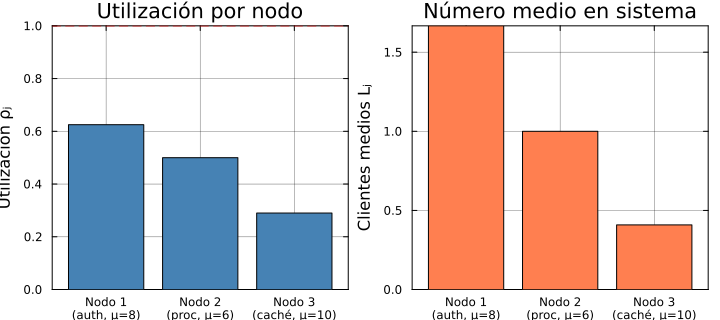

In [7]:
# Visualización: utilización y clientes medios por nodo
nodos = ["Nodo 1\n(auth, μ=8)", "Nodo 2\n(proc, μ=6)", "Nodo 3\n(caché, μ=10)"]

p1 = bar(nodos, res3.ρ, ylabel="Utilización ρⱼ", title="Utilización por nodo",
         color=:steelblue, legend=false, ylims=(0,1))
hline!([1.0], linestyle=:dash, color=:red, label="ρ=1")

p2 = bar(nodos, res3.L, ylabel="Clientes medios Lⱼ", title="Número medio en sistema",
         color=:coral, legend=false)

plot(p1, p2, layout=(1,2), size=(720,320))

### Análisis del cuello de botella

En una red en tándem, el **cuello de botella** es el nodo con mayor utilización $\rho_j$. Cuando la tasa de llegadas se acerca a la capacidad del cuello de botella, el tiempo de espera en ese nodo domina el tiempo total en la red.

Analizamos cómo varía $W$ al aumentar la tasa de llegadas en la red del Ejemplo 1. El cuello de botella es el nodo 2 ($\mu_2 = 4$), así que el sistema es estable solo para $\lambda < 4$.

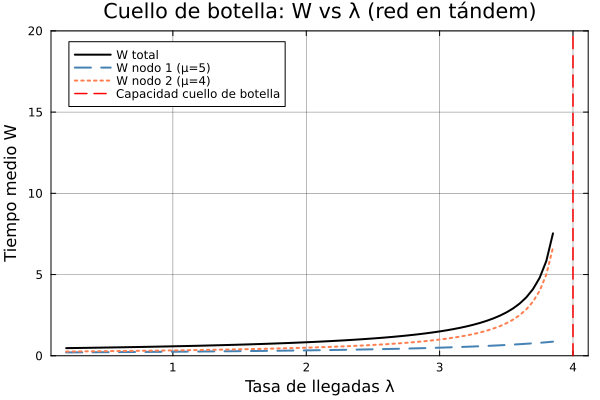

In [8]:
λ_range = 0.2:0.05:3.85
μ_cb = [5.0, 4.0]
R_cb = [0.0 1.0; 0.0 0.0]

W_red  = Float64[]
W_n1   = Float64[]
W_n2   = Float64[]

for λ in λ_range
    λv = trafico_jackson([λ, 0.0], R_cb)
    push!(W_red, mm1_W(λv[1], μ_cb[1]) + mm1_W(λv[2], μ_cb[2]))
    push!(W_n1,  mm1_W(λv[1], μ_cb[1]))
    push!(W_n2,  mm1_W(λv[2], μ_cb[2]))
end

plot(λ_range, W_red, label="W total",       lw=2, color=:black)
plot!(λ_range, W_n1, label="W nodo 1 (μ=5)", lw=2, color=:steelblue, linestyle=:dash)
plot!(λ_range, W_n2, label="W nodo 2 (μ=4)", lw=2, color=:coral,     linestyle=:dot)
vline!([4.0], label="Capacidad cuello de botella", lw=1.5, color=:red, linestyle=:dash)
plot!(xlabel="Tasa de llegadas λ", ylabel="Tiempo medio W",
      title="Cuello de botella: W vs λ (red en tándem)",
      legend=:topleft, ylims=(0, 20))

Cuando $\lambda \to \mu_2 = 4$, el tiempo en el nodo 2 diverge como $1/(\mu_2 - \lambda)$, dominando completamente el tiempo total en la red. El nodo 1 permanece con carga moderada porque $\mu_1 > \mu_2$.

### Simulación y verificación del teorema

Verificamos el teorema de Jackson simulando la red en tándem del Ejemplo 1 y comparando la distribución empírica de $(n_1, n_2)$ con el producto de las distribuciones marginales M/M/1.

In [9]:
"""
Simulación por eventos discretos de una red de Jackson con nodos M/M/1.
Retorna el vector de tiempos medios L[j] = E[nⱼ] estimado por integración temporal.
"""
function simular_jackson(ν, μ, R; T_max=200_000.0, seed=42)
    Random.seed!(seed)
    J  = length(ν)
    n  = zeros(Int, J)           # estado actual
    t  = 0.0
    L_acum = zeros(Float64, J)   # ∫ nⱼ(t) dt

    while t < T_max
        # Tasas de todos los eventos posibles
        tasa_lleg    = sum(ν)
        tasas_serv   = [n[j] > 0 ? μ[j] : 0.0 for j in 1:J]
        tasa_total   = tasa_lleg + sum(tasas_serv)
        tasa_total == 0.0 && break

        # Tiempo hasta próximo evento
        Δt = randexp() / tasa_total
        Δt_ef = min(Δt, T_max - t)
        L_acum .+= n .* Δt_ef
        t += Δt
        t > T_max && break

        # Seleccionar evento con probabilidad proporcional a su tasa
        u = rand() * tasa_total
        acum = 0.0
        evento  = :ninguno
        nodo_ev = 0

        # ¿Es una llegada externa?
        for j in 1:J
            acum += ν[j]
            if u < acum
                evento  = :llegada
                nodo_ev = j
                break
            end
        end

        # ¿Es un fin de servicio?
        if evento == :ninguno
            for j in 1:J
                acum += tasas_serv[j]
                if u < acum
                    evento  = :servicio
                    nodo_ev = j
                    break
                end
            end
        end

        # Ejecutar evento
        if evento == :llegada
            n[nodo_ev] += 1
        elseif evento == :servicio
            n[nodo_ev] -= 1
            # Rutear al siguiente nodo
            r = rand()
            acum_r = 0.0
            for k in 1:J
                acum_r += R[nodo_ev, k]
                if r < acum_r
                    n[k] += 1
                    break
                end
                # si r >= sum(R[j,:]) el cliente sale de la red
            end
        end
    end

    return L_acum ./ T_max
end

simular_jackson

In [10]:
# Verificación numérica para los tres ejemplos
ejemplos = [
    ("Tándem",          ν1, μ1, R1, res1),
    ("Retroalimentación", ν2, μ2, R2, res2),
    ("Tres nodos",      ν3, μ3, R3, res3),
]

for (nombre, λe, μv, Rv, res) in ejemplos
    L_sim = simular_jackson(λe, μv, Rv)
    println("Ejemplo: $nombre")
    println(@sprintf "  %-8s %-12s %-12s %-10s" "Nodo" "L (teórico)" "L (simul.)" "Error %")
    println("  " * "-"^44)
    for j in 1:length(μv)
        err = abs(L_sim[j] - res.L[j]) / res.L[j] * 100
        println(@sprintf "  %-8d %-12.4f %-12.4f %-10.2f" j res.L[j] L_sim[j] err)
    end
    println()
end

Ejemplo: Tándem
  Nodo     L (teórico)  L (simul.)   Error %   
  --------------------------------------------
  1        1.5000       1.4867       0.89      
  2        3.0000       2.9654       1.15      

Ejemplo: Retroalimentación
  Nodo     L (teórico)  L (simul.)   Error %   
  --------------------------------------------
  1        0.9091       0.9090       0.01      
  2        1.0000       0.9972       0.28      

Ejemplo: Tres nodos
  Nodo     L (teórico)  L (simul.)   Error %   
  --------------------------------------------
  1        1.6667       1.6573       0.56      
  2        1.0000       0.9948       0.52      
  3        0.4085       0.4106       0.52      



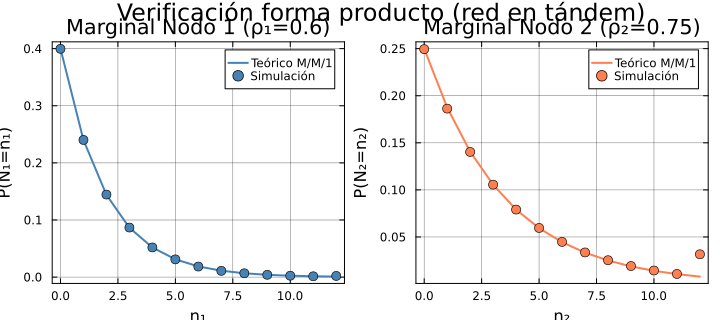

In [11]:
# Verificación de la forma producto: comparamos π(n₁,n₂) empírica vs teórica
# para la red en tándem
"""
Versión que registra la distribución conjunta empírica de (n₁, n₂).
"""
function simular_jackson_dist(ν, μ, R; T_max=500_000.0, N_max=15, seed=42)
    Random.seed!(seed)
    J = length(ν)
    n = zeros(Int, J)
    t = 0.0
    dist = zeros(Float64, N_max+1, N_max+1)   # dist[n₁+1, n₂+1]

    while t < T_max
        tasas_serv = [n[j] > 0 ? μ[j] : 0.0 for j in 1:J]
        tasa_total = sum(ν) + sum(tasas_serv)
        tasa_total == 0.0 && break

        Δt = randexp() / tasa_total
        Δt_ef = min(Δt, T_max - t)
        i1 = min(n[1], N_max) + 1
        i2 = min(n[2], N_max) + 1
        dist[i1, i2] += Δt_ef
        t += Δt
        t > T_max && break

        u = rand() * tasa_total
        acum = 0.0
        evento = :ninguno; nodo_ev = 0
        for j in 1:J
            acum += ν[j]
            if u < acum; evento = :llegada; nodo_ev = j; break; end
        end
        if evento == :ninguno
            for j in 1:J
                acum += tasas_serv[j]
                if u < acum; evento = :servicio; nodo_ev = j; break; end
            end
        end
        if evento == :llegada
            n[nodo_ev] += 1
        elseif evento == :servicio
            n[nodo_ev] -= 1
            r = rand(); acum_r = 0.0
            for k in 1:J
                acum_r += R[nodo_ev, k]
                if r < acum_r; n[k] += 1; break; end
            end
        end
    end
    return dist ./ T_max
end

N_max = 12
π_sim = simular_jackson_dist(ν1, μ1, R1; N_max=N_max)

# Distribución teórica producto-forma
ρ1, ρ2 = res1.ρ
π_teo = [(1-ρ1)*ρ1^n1 * (1-ρ2)*ρ2^n2
         for n1 in 0:N_max, n2 in 0:N_max]

# Comparar distribuciones marginales
π1_sim = sum(π_sim, dims=2)[:]
π1_teo = [(1-ρ1)*ρ1^n for n in 0:N_max]
π2_sim = sum(π_sim, dims=1)[:]
π2_teo = [(1-ρ2)*ρ2^n for n in 0:N_max]

ns = 0:N_max
p1 = plot(ns, π1_teo, label="Teórico M/M/1", lw=2, color=:steelblue)
scatter!(ns, π1_sim, label="Simulación", ms=5, color=:steelblue)
plot!(xlabel="n₁", ylabel="P(N₁=n₁)", title="Marginal Nodo 1 (ρ₁=$(round(ρ1,digits=2)))")

p2 = plot(ns, π2_teo, label="Teórico M/M/1", lw=2, color=:coral)
scatter!(ns, π2_sim, label="Simulación", ms=5, color=:coral)
plot!(xlabel="n₂", ylabel="P(N₂=n₂)", title="Marginal Nodo 2 (ρ₂=$(round(ρ2,digits=2)))")

plot(p1, p2, layout=(1,2), size=(720,320),
     plot_title="Verificación forma producto (red en tándem)")

La simulación confirma que las distribuciones marginales son exactamente geométricas (M/M/1), validando el teorema de Jackson.

Podemos ir un paso más allá y verificar la **independencia**: si $\pi(n_1,n_2) = \pi_1(n_1)\pi_2(n_2)$, entonces la distribución conjunta debe factorizarse exactamente.

## Resumen

| Concepto | Resultado |
|---|---|
| Ecuaciones de tráfico | $(I - R^T)\boldsymbol{\lambda} = \boldsymbol{\nu}$ |
| Teorema de Jackson | $\pi(\mathbf{n}) = \prod_j (1-\rho_j)\rho_j^{n_j}$ |
| Independencia en estado estacionario | Los nodos son M/M/1 independientes con tasas $\lambda_j$ |
| Prueba | Balance global + ecuaciones de tráfico + conservación de flujo |

**Hipótesis del teorema:**
- Llegadas externas Poisson, independientes entre nodos.
- Tiempos de servicio exponenciales, independientes entre sí y de las llegadas.
- Ruteo Markoviano independiente (probabilidades $r_{jk}$ fijas).
- Disciplina FCFS en cada nodo (también vale para PS y LCFS-PR).
- $\rho_j < 1$ en cada nodo.

**Generalización.** El resultado se extiende a nodos con múltiples servidores M/M/$c_j$, con la distribución marginal de cada nodo siendo la de una cola M/M/$c_j$ con tasa $\lambda_j$. Las ecuaciones de tráfico son idénticas; solo cambian las fórmulas de performance por nodo.